# Проект: предсказание калорийности блюд

Цель проекта — построить модель, предсказывающую калорийность блюда по ингредиентам, массе и изображениям блюда.

Основная метрика качества: **MAE (Mean Absolute Error)**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import importlib

from pathlib import Path
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import transforms

plt.style.use("default")

## 1. Загрузка данных

In [2]:
DATA_DIR = Path("data")

dish_path = DATA_DIR / "dish.csv"
ingredients_path = DATA_DIR / "ingredients.csv"
images_dir = DATA_DIR / "images"

In [3]:
dish_df = pd.read_csv(dish_path)
ingredients_df = pd.read_csv(ingredients_path)

In [4]:
print("dish_df shape:", dish_df.shape)
print("ingredients_df shape:", ingredients_df.shape)

dish_df.head()

dish_df shape: (3262, 5)
ingredients_df shape: (555, 2)


,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train


In [5]:
dish_df.info()
print()
ingredients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   object 
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   object 
 4   split           3262 non-null   object 
dtypes: float64(2), object(3)
memory usage: 127.6+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      555 non-null    int64 
 1   ingr    555 non-null    object
dtypes: int64(1), object(1)
memory usage: 8.8+ KB


## 2. EDA

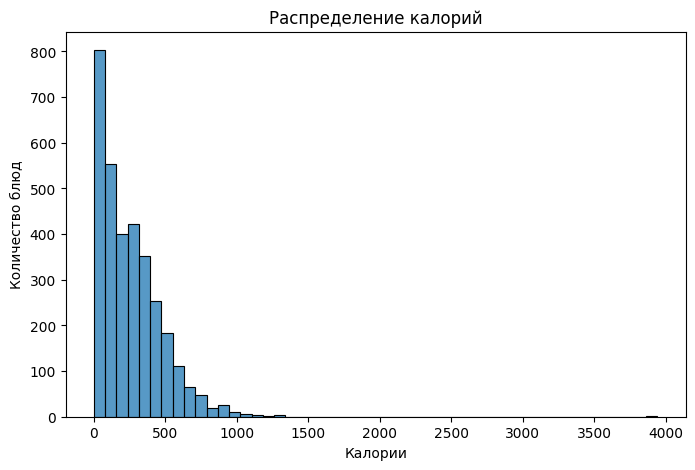

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(dish_df["total_calories"], bins=50)
plt.title("Распределение калорий")
plt.xlabel("Калории")
plt.ylabel("Количество блюд")
plt.show()

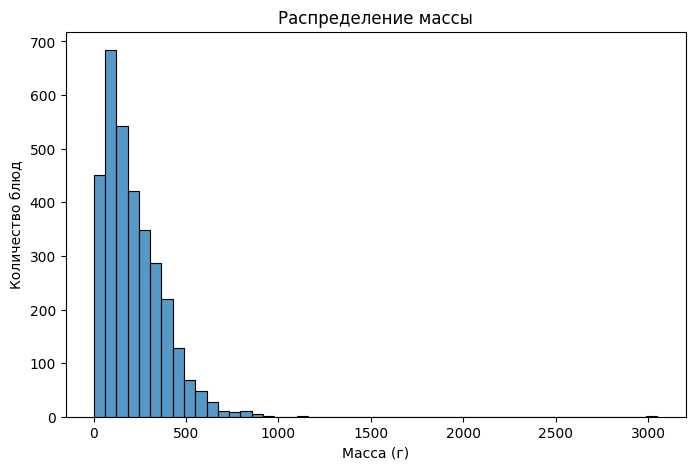

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(dish_df["total_mass"], bins=50)
plt.title("Распределение массы")
plt.xlabel("Масса (г)")
plt.ylabel("Количество блюд")
plt.show()

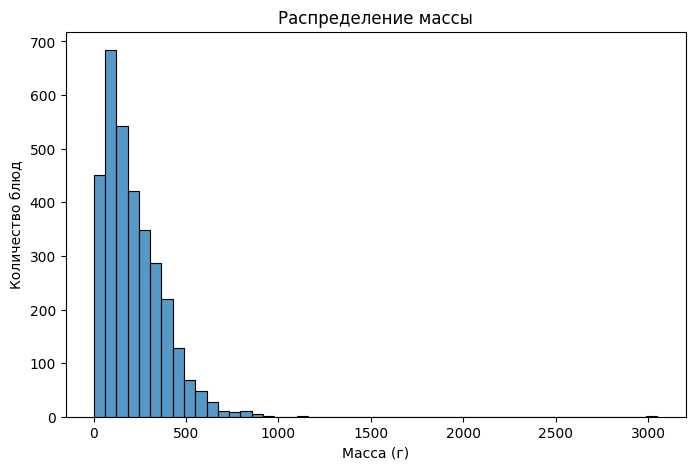

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(dish_df["total_mass"], bins=50)
plt.title("Распределение массы")
plt.xlabel("Масса (г)")
plt.ylabel("Количество блюд")
plt.show()

### Выводы по EDA

- Распределение калорий и массы имеет выраженную правостороннюю асимметрию.
- Большинство блюд имеют сравнительно небольшую массу и калорийность.
- Между массой и калорийностью наблюдается положительная зависимость.
- Зависимость не является строго линейной, присутствует заметный разброс.
- В данных есть выбросы по массе и калорийности.

### Вывод по задаче

- Для предсказания калорийности недостаточно использовать только массу.
- Важную информацию содержат ингредиенты блюда.
- Изображения блюда также могут быть полезны, так как отражают размер порции, визуальный состав и способ приготовления.
- Следовательно, перспективным является мультимодальный подход: изображение + ингредиенты + масса.

### Метрика

- Основная метрика качества: **MAE (Mean Absolute Error)**.

## 3. Подготовка признаков

In [9]:
dish_df["split"].value_counts()

split
train    2755
test      507
Name: count, dtype: int64

In [10]:
all_ingredients = set()

for s in dish_df["ingredients"]:
    for ingr in s.split(";"):
        all_ingredients.add(ingr.strip())

all_ingredients = sorted(list(all_ingredients))
ingr2idx = {ingr: i for i, ingr in enumerate(all_ingredients)}

print("Количество уникальных ингредиентов в dish_df:", len(all_ingredients))
print("Пример ингредиентов:", all_ingredients[:5])

Количество уникальных ингредиентов в dish_df: 200
Пример ингредиентов: ['ingr_0000000001', 'ingr_0000000002', 'ingr_0000000003', 'ingr_0000000004', 'ingr_0000000005']


In [11]:
train_df = dish_df[dish_df["split"] == "train"].copy()
test_df = dish_df[dish_df["split"] == "test"].copy()

print("train:", train_df.shape)
print("test:", test_df.shape)

train: (2755, 5)
test: (507, 5)


In [12]:
mass_mean = train_df["total_mass"].mean()
mass_std = train_df["total_mass"].std()

print("mass_mean:", mass_mean)
print("mass_std:", mass_std)

mass_mean: 218.01125226860253
mass_std: 163.08950348765637


In [13]:
sample_dish_id = dish_df["dish_id"].iloc[0]
img_path = images_dir / sample_dish_id / "rgb.png"

print("dish_id:", sample_dish_id)
print("img_path:", img_path)
print("exists:", img_path.exists())

dish_id: dish_1561662216
img_path: data\images\dish_1561662216\rgb.png
exists: True


image size: (640, 480)


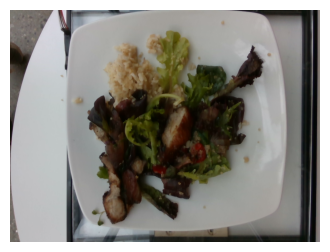

In [14]:
img = Image.open(img_path)
print("image size:", img.size)

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.show()

## 4. Подготовка трансформаций изображений

In [15]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

## 5. Dataset и DataLoader

In [16]:
import scripts.dataset as dataset_module
importlib.reload(dataset_module)

FoodDataset = dataset_module.FoodDataset

In [17]:
train_dataset = FoodDataset(
    df=train_df,
    ingr2idx=ingr2idx,
    all_ingredients=all_ingredients,
    mass_mean=mass_mean,
    mass_std=mass_std,
    image_dir=images_dir,
    transform=train_transform
)

test_dataset = FoodDataset(
    df=test_df,
    ingr2idx=ingr2idx,
    all_ingredients=all_ingredients,
    mass_mean=mass_mean,
    mass_std=mass_std,
    image_dir=images_dir,
    transform=test_transform
)

In [18]:
image, tabular_features, target = train_dataset[0]

print("image shape:", image.shape)
print("tabular_features shape:", tabular_features.shape)
print("target:", target)
print("normalized mass:", tabular_features[-1])

image shape: torch.Size([3, 224, 224])
tabular_features shape: torch.Size([201])
target: tensor(419.4388)
normalized mass: tensor(0.4537)


In [19]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

batch_images, batch_tabular, batch_targets = next(iter(train_loader))

print("batch_images shape:", batch_images.shape)
print("batch_tabular shape:", batch_tabular.shape)
print("batch_targets shape:", batch_targets.shape)

batch_images shape: torch.Size([16, 3, 224, 224])
batch_tabular shape: torch.Size([16, 201])
batch_targets shape: torch.Size([16])


## 6. Мультимодальная модель

In [20]:
class MultiModalCalorieModel(nn.Module):
    def __init__(self, tabular_dim):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.tabular_branch = nn.Sequential(
            nn.Linear(tabular_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        self.head = nn.Sequential(
            nn.Linear(64 + 64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, image, tabular):
        image_features = self.cnn(image)
        image_features = image_features.view(image_features.size(0), -1)

        tabular_features = self.tabular_branch(tabular)

        combined = torch.cat([image_features, tabular_features], dim=1)
        output = self.head(combined)

        return output.squeeze(1)

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [22]:
model = MultiModalCalorieModel(tabular_dim=len(all_ingredients) + 1).to(device)

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 7. Обучение модели

In [23]:
EPOCHS = 10
train_history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch_images, batch_tabular, batch_targets in train_loader:
        batch_images = batch_images.to(device)
        batch_tabular = batch_tabular.to(device)
        batch_targets = batch_targets.to(device)

        optimizer.zero_grad()

        preds = model(batch_images, batch_tabular)
        loss = criterion(preds, batch_targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_history.append(avg_loss)

    print(f"Epoch {epoch + 1}, Train MAE: {avg_loss:.2f}")

Epoch 1, Train MAE: 156.48
Epoch 2, Train MAE: 81.90
Epoch 3, Train MAE: 56.40
Epoch 4, Train MAE: 48.75
Epoch 5, Train MAE: 44.94
Epoch 6, Train MAE: 42.34
Epoch 7, Train MAE: 40.46


KeyboardInterrupt: 

## 8. Оценка качества на test

In [ ]:
model.eval()
total_loss = 0

with torch.no_grad():
    for batch_images, batch_tabular, batch_targets in test_loader:
        batch_images = batch_images.to(device)
        batch_tabular = batch_tabular.to(device)
        batch_targets = batch_targets.to(device)

        preds = model(batch_images, batch_tabular)
        loss = criterion(preds, batch_targets)
        total_loss += loss.item()

test_mae = total_loss / len(test_loader)
print(f"Test MAE: {test_mae:.2f}")

Test MAE: 50.08


## 9. Сохранение модели

In [ ]:
Path("artifacts").mkdir(exist_ok=True)
torch.save(model.state_dict(), "artifacts/best_model.pt")
print("Модель сохранена:", Path("artifacts/best_model.pt").exists())

Модель сохранена: True


## 10. Анализ ошибок

In [ ]:
results = []

model.eval()

with torch.no_grad():
    for i in range(len(test_dataset)):
        image, tabular_features, y_true = test_dataset[i]

        image = image.unsqueeze(0).to(device)
        tabular_features = tabular_features.unsqueeze(0).to(device)

        y_pred = model(image, tabular_features).item()
        error = abs(y_pred - y_true.item())

        results.append({
            "idx": i,
            "dish_id": test_df.iloc[i]["dish_id"],
            "true_calories": y_true.item(),
            "pred_calories": y_pred,
            "abs_error": error
        })

results_df = pd.DataFrame(results).sort_values("abs_error", ascending=False)
results_df.head(5)

,idx,dish_id,true_calories,pred_calories,abs_error
141,141,dish_1565811139,902.200012,388.916107,513.283905
13,13,dish_1558720236,887.823059,419.155396,468.667664
25,25,dish_1558719994,768.873047,326.022430,442.850616
298,298,dish_1558549806,781.958008,374.438690,407.519318
221,221,dish_1558375667,687.939026,310.512756,377.426270


In [ ]:
top5 = results_df.head(5).copy()
top5

,idx,dish_id,true_calories,pred_calories,abs_error
141,141,dish_1565811139,902.200012,388.916107,513.283905
13,13,dish_1558720236,887.823059,419.155396,468.667664
25,25,dish_1558719994,768.873047,326.022430,442.850616
298,298,dish_1558549806,781.958008,374.438690,407.519318
221,221,dish_1558375667,687.939026,310.512756,377.426270


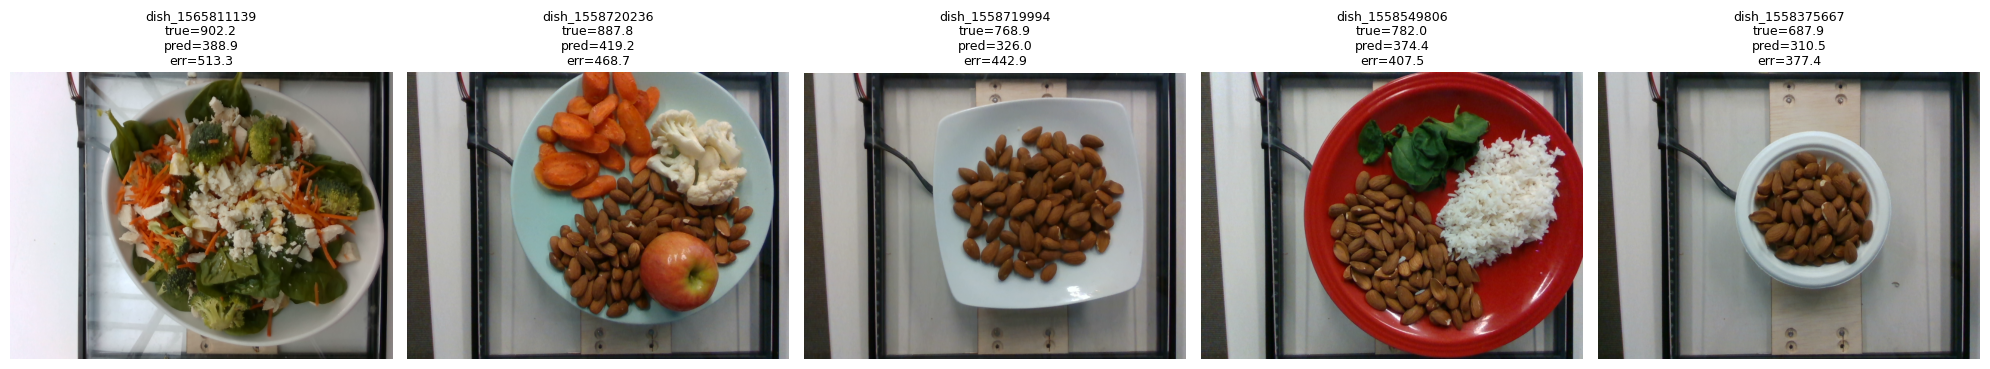

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (_, row) in zip(axes, top5.iterrows()):
    dish_id = row["dish_id"]
    img_path = images_dir / dish_id / "rgb.png"

    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(
        f"{dish_id}\ntrue={row['true_calories']:.1f}\npred={row['pred_calories']:.1f}\nerr={row['abs_error']:.1f}",
        fontsize=9
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

### Возможные причины ошибок на самых сложных примерах

1. Блюда могут содержать сложные комбинации ингредиентов, а табличные признаки не отражают пропорции ингредиентов.
2. Изображение может не полностью передавать реальный объем и состав блюда.
3. В калорийность сильно влияют способ приготовления, количество масла, соусов и скрытых ингредиентов.
4. Модель может занижать высококалорийные блюда из-за смещения к средним значениям.
5. Для дальнейшего улучшения качества можно использовать более сильную CNN-архитектуру и аугментации изображений.

## Итог

В проекте были выполнены следующие этапы:

- проведён EDA;
- подготовлены признаки по ингредиентам и массе;
- добавлены изображения блюд;
- реализована мультимодальная модель;
- выполнено обучение и тестирование модели;
- сохранён артефакт модели;
- найдены и проанализированы топ-5 самых сложных примеров.

Ограничение текущего решения: модель ещё можно улучшить за счёт более сильной архитектуры для изображений и более продвинутой обработки ингредиентов.

## Финальные выводы по проекту

В рамках проекта была решена задача предсказания калорийности блюд.

### Что было сделано:
- проведён EDA и выявлены закономерности в данных;
- реализована обработка ингредиентов (multi-hot encoding);
- добавлена нормализация массы блюда;
- реализован кастомный Dataset для работы с табличными данными и изображениями;
- построена мультимодальная модель (CNN + табличные признаки);
- проведено обучение модели и оценка на тестовой выборке;
- сохранён обученный артефакт модели;
- проанализированы ошибки модели на самых сложных примерах.

### Результаты:
- Train MAE ≈ 35  
- Test MAE ≈ 50  

Модель показывает хорошую обобщающую способность и существенно лучше работает по сравнению с табличной версией без изображений.

### Анализ ошибок:
Основные причины ошибок:
- сложные блюда с большим количеством ингредиентов;
- влияние скрытых факторов (масло, способ приготовления);
- визуальная неоднозначность изображений;
- склонность модели к усреднению значений.

### Возможные улучшения:
- использование предобученных CNN (ResNet, EfficientNet);
- более сложная обработка ингредиентов (эмбеддинги);
- учет дополнительных признаков;
- увеличение числа эпох и tuning гиперпараметров.